In [1]:
import pandas as pd
import numpy as np
import requests
from io import StringIO
import scipy
import os
import datetime as dt

import seaborn as sns
import matplotlib.pyplot as plt

# import tensorflow as tf
# from tensorflow import keras
# from tensorflow.keras import layers
# from tensorflow.keras.models import load_model
# from tensorflow.keras.layers import Dense, Input
# import tensorflow_addons as tfa


# Carga de datos

In [2]:
url = "https://zenodo.org/records/10723261/files/Weather_data.mat"
mat_file = "..\\data\\Weather_data.mat"

In [3]:
if os.path.exists(mat_file):
    ws_data = scipy.io.loadmat(mat_file)
    print("Se carga el archivo mat")

else:

    response = requests.get(url)
    # Verificar que la descarga fue exitosa
    if response.status_code == 200:
        with open(mat_file, "wb") as f:
            f.write(response.content)
        print(f"Archivo guardado como: {mat_file}")
        ws_data = scipy.io.loadmat(mat_file)
        print("Se carga el archivo mat")
    else:
        print(f"Error al descargar: {response.status_code}")

Se carga el archivo mat


# Preprocesamiento

Se convierte a tiempo continuo: desde el formato decha a segundos

In [4]:
date_0 = ws_data['Date'][0]
date = []
for i in range(0, len(date_0)):
    date = np.append(date, str(date_0[i])[2 : -2])
time_init = dt.datetime(int(date[0][0 : 4]), int(date[0][5 : 7]), int(date[0][8 : 10]), int(date[0][11 : 13]), int(date[0][14 : 16]))
T_nan_index = np.argwhere(pd.isna(date))
date = np.delete(date, T_nan_index[:, 0],  0)
print('Double-check for NaN in time sequence', np.sum(pd.isna(date)))

Double-check for NaN in time sequence 0


In [5]:
Seconds = np.zeros((date.shape[0], 1))
for index in range(date.shape[0]):
    Seconds[index, 0] = ((dt.datetime(int(date[index][0 : 4]), int(date[index][5 : 7]), int(date[index][8 : 10]), int(date[index][11 : 13]), int(date[index][14 : 16])) - time_init).total_seconds())
T_WS = Seconds

Se convierte a coordenadas cartesianas

In [6]:
X_WS = np.array(6378000 * np.sin(np.radians(ws_data['Lon'])))[0]  # Longitude to meters
Y_WS = np.array(6378000 * np.sin(np.radians(ws_data['Lat'])))[0]  # Latitude to meters
Z_WS = np.array(ws_data['Alt'])[0]
Temp_WS = np.array(ws_data['Temperature'])[0]

In [7]:
X_WS

array([443352.13315827, 605794.52824544, 620998.89701695, ...,
       620998.89701695, 686760.23713126, 605794.52824544])

Se proyecta la velocidad del viento y la dirección en las coordenadas cartesianas

In [8]:
U_WS = (ws_data['WindSpeed'] * ws_data['WindDirectionX'])[0]
V_WS = (ws_data['WindSpeed'] * ws_data['WindDirectionY'])[0]

Presión de mbar a Pa

In [9]:
P_WS = ws_data['Pressure'][0] * 100

Removiendo valores `NaN`

In [10]:
X_WS = np.delete(X_WS, T_nan_index[:, 0],  0)
Y_WS = np.delete(Y_WS, T_nan_index[:, 0],  0)
Z_WS = np.delete(Z_WS, T_nan_index[:, 0],  0)
U_WS = np.delete(U_WS, T_nan_index[:, 0],  0)
V_WS = np.delete(V_WS, T_nan_index[:, 0],  0)
P_WS = np.delete(P_WS, T_nan_index[:, 0],  0)
Temp_WS = np.delete(Temp_WS, T_nan_index[:, 0],  0)

In [11]:
T_WS.shape

(42336, 1)

Se estructura la información en una matriz: 21 estaciones `(filas)` $\times$ medidas cada 10 min `(columnas)`

In [12]:
T_WS = np.reshape(T_WS, (int(T_WS.shape[0] / 21), 21)).T # There are 21 WS stations in this case
X_WS = np.reshape(X_WS, (T_WS.shape[1], T_WS.shape[0])).T
Y_WS = np.reshape(Y_WS, (T_WS.shape[1], T_WS.shape[0])).T
Z_WS = np.reshape(Z_WS, (T_WS.shape[1], T_WS.shape[0])).T
U_WS = np.reshape(U_WS, (T_WS.shape[1], T_WS.shape[0])).T
V_WS = np.reshape(V_WS, (T_WS.shape[1], T_WS.shape[0])).T
P_WS = np.reshape(P_WS, (T_WS.shape[1], T_WS.shape[0])).T
Temp_WS = np.reshape(Temp_WS, (T_WS.shape[1], T_WS.shape[0])).T
print('Number of weather stations:', T_WS.shape[0])

Number of weather stations: 21


In [13]:
T_WS.shape , X_WS.shape

((21, 2016), (21, 2016))

Se remueven los valores `NaN`

In [14]:
X_nan_index = np.argwhere(np.isnan(X_WS))
T_WS = np.delete(T_WS, X_nan_index[:, 0],  0)
P_WS = np.delete(P_WS, X_nan_index[:, 0],  0)
U_WS = np.delete(U_WS, X_nan_index[:, 0],  0)
V_WS = np.delete(V_WS, X_nan_index[:, 0],  0)
X_WS = np.delete(X_WS, X_nan_index[:, 0],  0)
Y_WS = np.delete(Y_WS, X_nan_index[:, 0],  0)
Z_WS = np.delete(Z_WS, X_nan_index[:, 0],  0)
Temp_WS = np.delete(Temp_WS, X_nan_index[:, 0],  0)
print('Double-check for NaN in location field', np.sum(np.isnan(X_WS)))

Double-check for NaN in location field 0


Se indica la cantidad de días

In [15]:
n_days = 14 # Change up to a maximum of 14 availsble days
samples =  int(144 * n_days) # Convert selected days to snapshots
T_WS = T_WS[:, : samples]
X_WS = X_WS[:, : samples]
Y_WS = Y_WS[:, : samples]
Z_WS = Z_WS[:, : samples]
U_WS = U_WS[:, : samples]
V_WS = V_WS[:, : samples]
P_WS = P_WS[:, : samples]
Temp_WS = Temp_WS[:, : samples]

Se ordena la matriz con el incremeto de los valores en la coordenada X

In [16]:
for snap in range(0, T_WS.shape[1]):
    index_sort = np.argsort(X_WS[:, snap])
    T_WS[:, snap] = T_WS[index_sort, snap]
    X_WS[:, snap] = X_WS[index_sort, snap]
    Y_WS[:, snap] = Y_WS[index_sort, snap]
    Z_WS[:, snap] = Z_WS[index_sort, snap]
    U_WS[:, snap] = U_WS[index_sort, snap]
    V_WS[:, snap] = V_WS[index_sort, snap]
    P_WS[:, snap] = P_WS[index_sort, snap]
    Temp_WS[:, snap] = Temp_WS[index_sort, snap]

Se eliminan los valores `NaN` de `U`, `V` y `P`

In [17]:
uvp_mean = np.nanmean(np.concatenate([U_WS, V_WS, P_WS], axis = 1), axis = 1)[:, None]
vel_nan_index = np.argwhere(np.isnan(uvp_mean))
T_WS = np.delete(T_WS, vel_nan_index[:, 0],  0)
P_WS = np.delete(P_WS, vel_nan_index[:, 0],  0)
U_WS = np.delete(U_WS, vel_nan_index[:, 0],  0)
V_WS = np.delete(V_WS, vel_nan_index[:, 0],  0)
X_WS = np.delete(X_WS, vel_nan_index[:, 0],  0)
Y_WS = np.delete(Y_WS, vel_nan_index[:, 0],  0)
Z_WS = np.delete(Z_WS, vel_nan_index[:, 0],  0)
Temp_WS = np.delete(Temp_WS, vel_nan_index[:, 0],  0)

In [18]:
X_WS[:,4]

array([295163.14760411, 347322.9856296 , 408223.59558935, 424453.56637646,
       443352.13315827, 484658.45788175, 485305.9276187 , 503155.58844348,
       510892.30066708, 517395.48588126, 521401.91855505, 529629.86361725,
       558898.0320129 , 562748.23756613, 584213.15507077, 595335.68012101,
       605794.52824544, 607179.68675625, 620998.89701695, 674800.52525466,
       686760.23713126])

Se corrige la presión para el nivel del mar (ISA)

In [19]:
P_WS = P_WS * (1 - 0.0065 * Z_WS / (Temp_WS + 273.15 + 0.0065 * Z_WS))**(-5.257)

Centrando los valores de localización y tiempo

In [20]:
x_min = np.min(X_WS)
x_max = np.max(X_WS)
X_WS = X_WS - (x_min + x_max) / 2
y_min = np.min(Y_WS)
y_max = np.max(Y_WS)
Y_WS = Y_WS - (y_min + y_max) / 2
t_min = np.min(T_WS)
t_max = np.max(T_WS)
T_WS = T_WS - t_min # Refer to t = 0

In [21]:
Y_WS.shape, X_WS.shape, T_WS.shape

print(
    T_WS[1,:9],"\n",
    X_WS[1,:9],"\n",
    Y_WS[1,:9],"\n",
)

[   0.  600. 1200. 1800. 2400. 3000. 3600. 4200. 4800.] 
 [-143638.70673808 -143638.70673808 -143638.70673808 -143638.70673808
 -143638.70673808 -143638.70673808 -143638.70673808 -143638.70673808
 -143638.70673808] 
 [30967.31993582 30967.31993582 30967.31993582 30967.31993582
 30967.31993582 30967.31993582 30967.31993582 30967.31993582
 30967.31993582] 



### Cuadricula de salida para la PINN

In [22]:
T_PINN = T_WS[0 : 1, :] # Same times for reconstruction

Resolución en grados $R = 0.2$

In [23]:
R = 0.2
R_PINN = 6378000 * np.sin(np.radians(R)) # Grid resolution
x_PINN = np.arange(x_min - R_PINN, x_max + R_PINN, R_PINN) # X values in output resolution
y_PINN = np.arange(y_min - R_PINN, y_max + R_PINN, R_PINN) # Y values in output resolution

Centrando la información de localización

In [24]:
x_PINN = x_PINN - (x_min + x_max) / 2
y_PINN = y_PINN - (y_min + y_max) / 2

In [25]:
x_PINN.shape,y_PINN.shape

((20,), (8,))

Cuadricula de salida final

In [26]:
X_PINN, Y_PINN = np.meshgrid(x_PINN, y_PINN)
X_PINN = X_PINN.flatten('F')[:, None]
Y_PINN = Y_PINN.flatten('F')[:, None]

Dimensiones

In [27]:
print(f"{T_PINN.shape=}")
print(f"{X_PINN.shape=}")
print(f"{Y_PINN.shape=}")

T_PINN.shape=(1, 2016)
X_PINN.shape=(160, 1)
Y_PINN.shape=(160, 1)


In [28]:
dim_T_PINN = T_PINN.shape[1]
dim_N_PINN = X_PINN.shape[0]

T_PINN = np.tile(T_PINN, (dim_N_PINN, 1))
X_PINN = np.tile(X_PINN, dim_T_PINN)
Y_PINN = np.tile(Y_PINN, dim_T_PINN)

In [29]:
print(f"{T_PINN.shape=}")
print(f"{X_PINN.shape=}")
print(f"{Y_PINN.shape=}")

T_PINN.shape=(160, 2016)
X_PINN.shape=(160, 2016)
Y_PINN.shape=(160, 2016)


Valores de referencia para la no-dimensionalización

In [30]:
L = np.sqrt((x_max - x_min) ** 2 + (y_max - y_min) ** 2) # Reference distance
W = np.sqrt(np.nanmax(abs(U_WS)) ** 2 + np.nanmax(abs(V_WS)) ** 2) # Reference velocity
rho = 1.269 # Air density at 15 degrees
nu = 1.382e-5 # Kinematic viscosity at 15 degrees
Re = int(W * L / nu) # Reynolds number
P0 = np.nanmean(P_WS) # Reference pressure level
print('L:', L, 'W', W, 'P0', P0, 'Re', Re)

L: 409791.6159110926 W 16.718180196652117 P0 100359.48707895375 Re 495728659759


No-dimensonalización

In [31]:
X_WS = X_WS / L
Y_WS = Y_WS / L
T_WS = T_WS * W / L
P_WS = (P_WS - P0) / rho / (W ** 2)
U_WS = U_WS / W
V_WS = V_WS / W

X_PINN = X_PINN / L
Y_PINN = Y_PINN / L
T_PINN = T_PINN * W / L

In [32]:
# Validation cases (remove stations)
# # N_test = 0 # Number of stations to remove
WS_val = np.array([1, 2, 3, 5, 7, 9, 10, 11, 13, 14, 15, 16, 19])
# Choose between different arrays for desired validation case:
# Close: np.array([2, 8, 10, 14, 16, 19])
# Far: np.array([0, 1, 4, 6, 8, 12, 17, 18, 19, 20])
# Envelope: np.array([1, 2, 3, 5, 7, 9, 10, 11, 13, 14, 15, 16, 19])

Se remueven WS para validación

In [33]:
T_val = T_WS[WS_val, :]
P_val = P_WS[WS_val, :]
U_val = U_WS[WS_val, :]
V_val = V_WS[WS_val, :]
X_val = X_WS[WS_val, :]
Y_val = Y_WS[WS_val, :]
Z_val = Z_WS[WS_val, :]

El resto de las WS para entrenamiento

In [34]:
T_WS = np.delete(T_WS, WS_val, 0)
P_WS = np.delete(P_WS, WS_val, 0)
U_WS = np.delete(U_WS, WS_val, 0)
V_WS = np.delete(V_WS, WS_val, 0)
X_WS = np.delete(X_WS, WS_val, 0)
Y_WS = np.delete(Y_WS, WS_val, 0)
print('Number of final weather stations available for training:', T_WS.shape[0])

Number of final weather stations available for training: 8


Dimensión

In [35]:
dim_N_WS = X_WS.shape[0]
dim_T_WS = X_WS.shape[1]

# del WS_data

# Gráficas

In [36]:
print(f"{X_WS.shape=}")
print(f"{Y_WS.shape=}")
print(f"{T_WS.shape=}")
print(f"{P_WS.shape=}")
print(f"{U_WS.shape=}")
print(f"{V_WS.shape=}")


X_WS.shape=(8, 2016)
Y_WS.shape=(8, 2016)
T_WS.shape=(8, 2016)
P_WS.shape=(8, 2016)
U_WS.shape=(8, 2016)
V_WS.shape=(8, 2016)


In [37]:
def info_estacion(n_estacion:int):
    fig, ax = plt.subplots(2,2,figsize=(9,6))
    ax[0,0].scatter(X_WS[:,0], Y_WS[:,0])
    ax[0,0].scatter(X_WS[n_estacion,:], Y_WS[n_estacion,:])
    ax[0,0].set_title("Posición")
    ax[0,0].grid()
    
    ax[0,1].plot(P_WS[n_estacion,:])
    ax[0,1].set_title("Presión")
    ax[0,1].grid()
    
    ax[1,0].plot(V_WS[n_estacion,:])
    ax[1,0].set_title("velocidad en v")
    ax[1,0].grid()

    ax[1,1].plot(U_WS[n_estacion,:])
    ax[1,1].set_title("velocidad en u")
    ax[1,1].grid()
    
    plt.show()

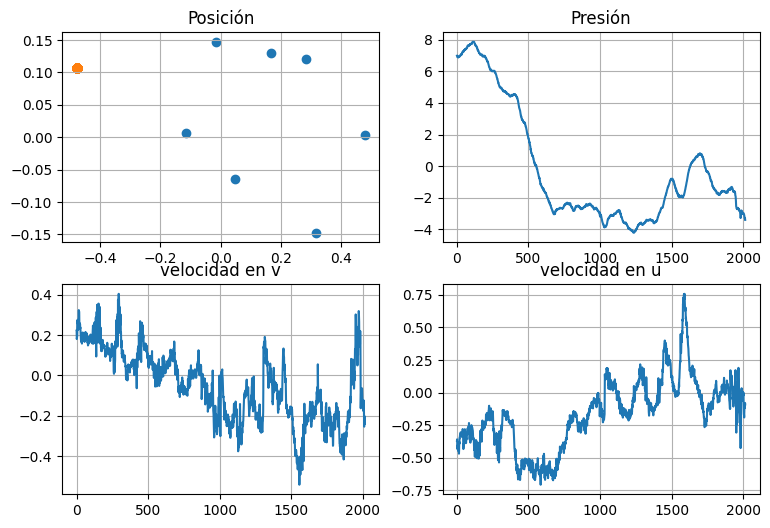

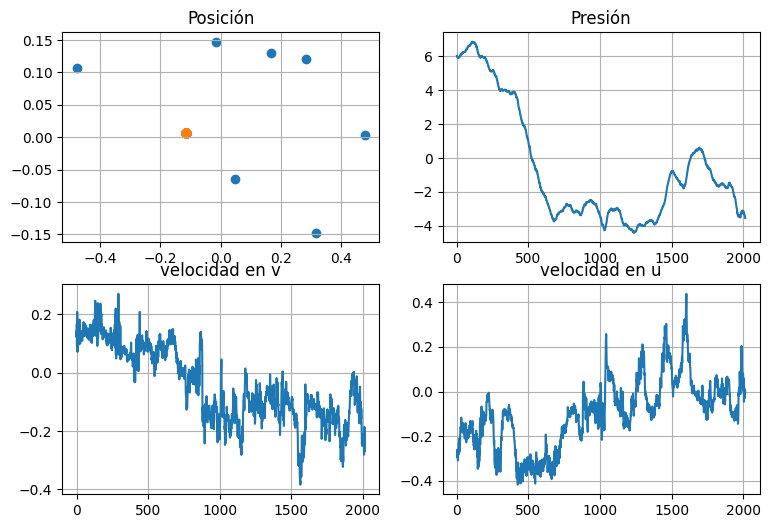

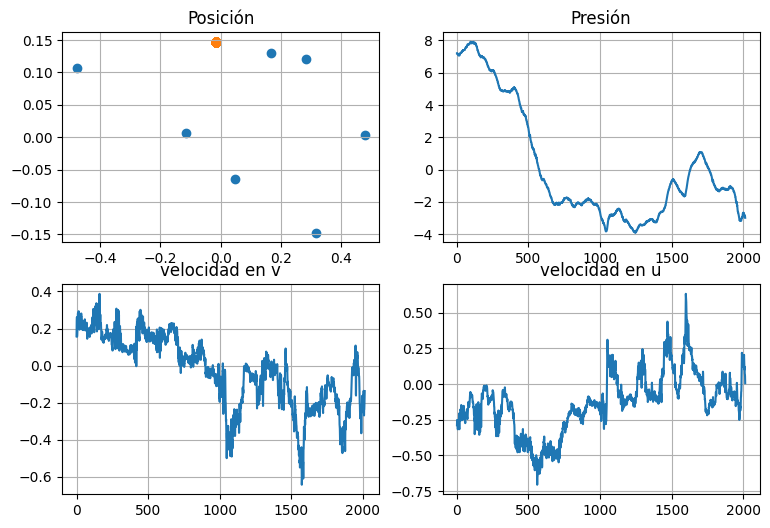

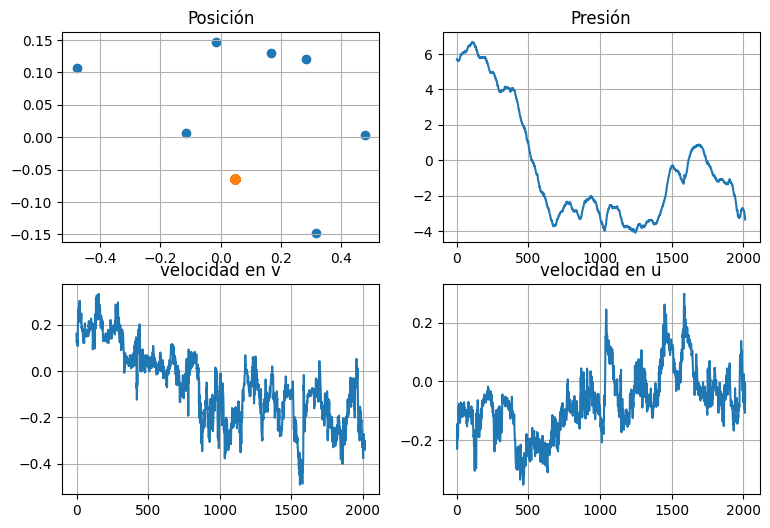

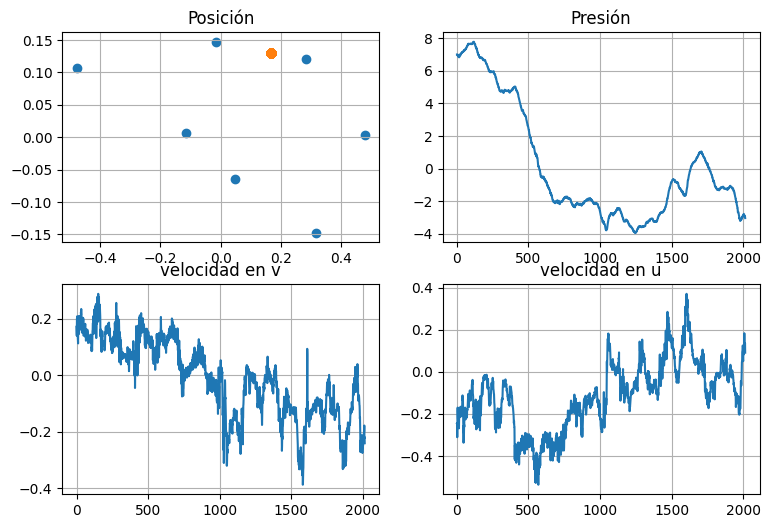

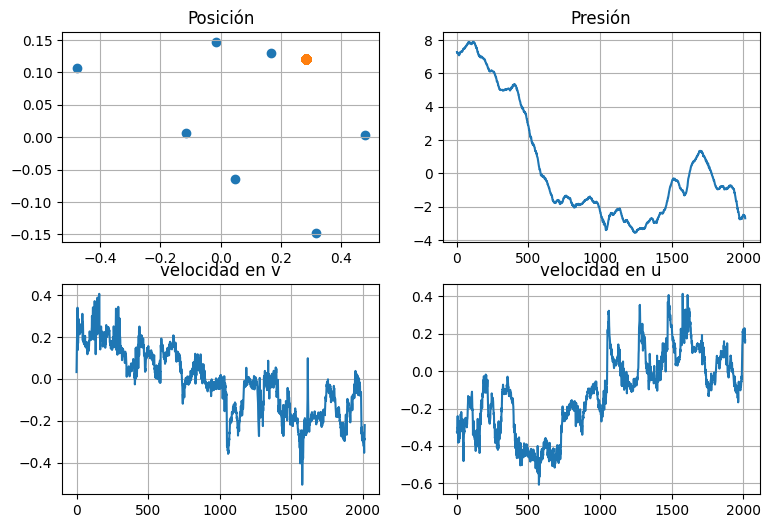

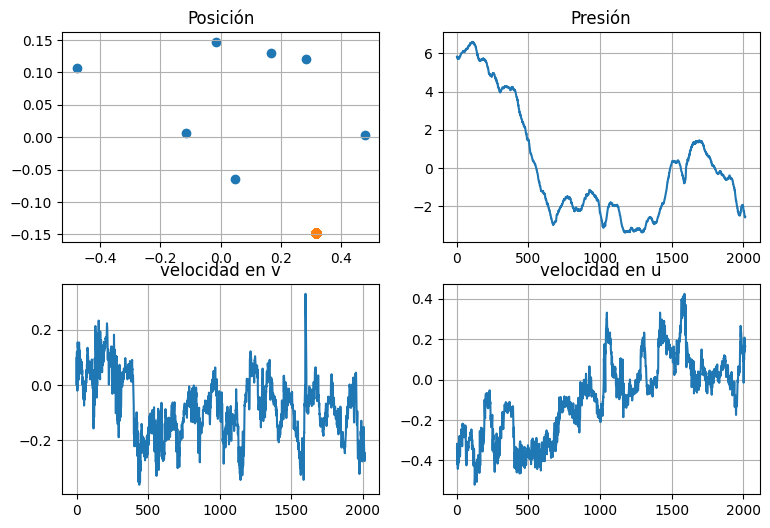

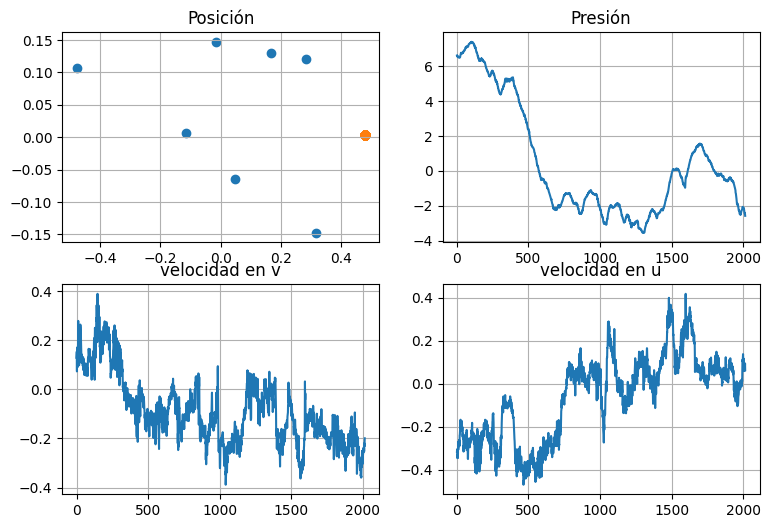

In [38]:
for n in range(0,8):
    info_estacion(n)

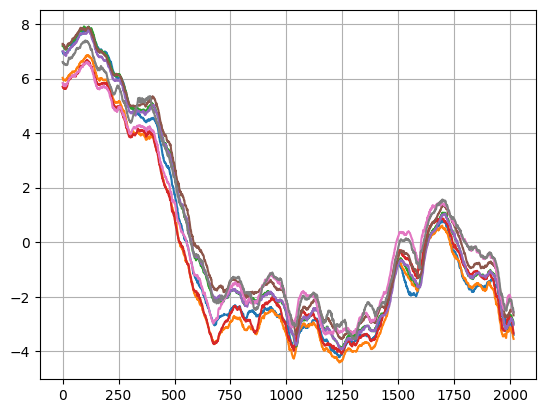

In [39]:
for i in range(P_WS.shape[0]):
    plt.plot(P_WS[i,:])
plt.grid()
plt.show()

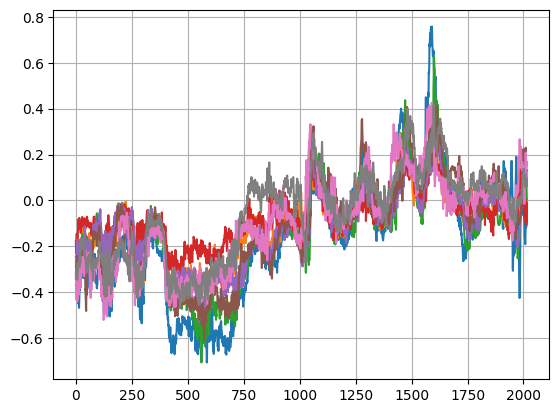

In [40]:
for i in range(U_WS.shape[0]):
    plt.plot(U_WS[i,:])
plt.grid()
plt.show()

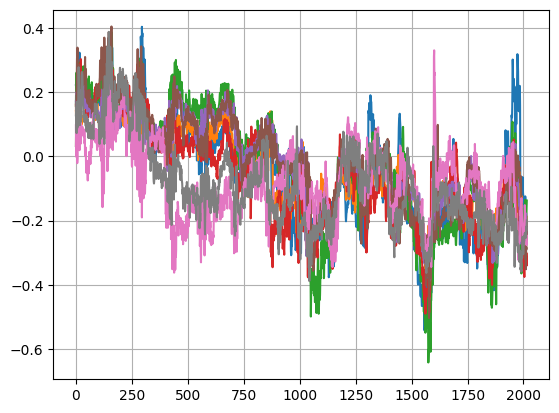

In [41]:
for i in range(V_WS.shape[0]):
    plt.plot(V_WS[i,:])
plt.grid()
plt.show()

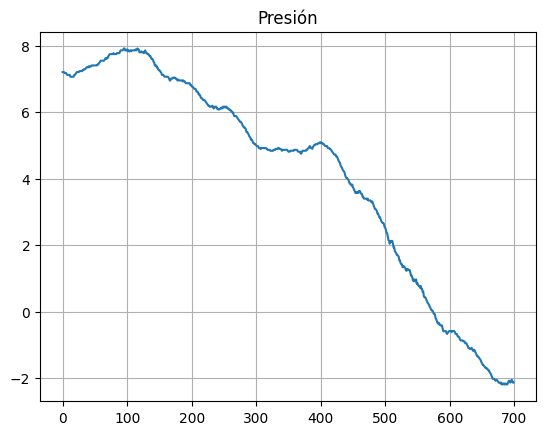

In [44]:
plt.plot(P_WS[2,:700])
plt.title("Presión")
plt.grid()
plt.show()